# Comparing Regression Model Families

Scikit-learn offers a dozen regressors behind one interface: `fit`, then `predict`. That uniformity
is convenient and slightly misleading, because the families behind it make genuinely different
assumptions about what a function looks like. A linear model can only draw a straight line. A
decision tree can only draw a staircase. K-nearest-neighbors has no functional form at all.

Here we fit eleven models — several families, several settings each — to the *same* noisy sine wave
and look at all of them the same way. The point is not to crown a winner. It is to see the
characteristic shape each family imposes, and how badly each behaves when asked about data it never
saw.

## Learning objectives

- Fit several scikit-learn regressors through the common `fit` / `predict` interface
- Recognize each family's characteristic prediction shape: line, staircase, local average, smooth curve
- Score models with $R^2$ and mean squared error on both the training and test splits
- Diagnose overfitting from a train-versus-test gap
- Show that every one of these models fails to extrapolate, and explain why

## Background

This notebook assumes a train/test split separates data used for fitting from data used for
judging, and nothing about the individual model families — each is introduced where it appears.

The two scoring formulas are given in section 4 where they are first computed.

**Prerequisites:** none. `U1-3_Regression-2_Overfitting` examines the train/test gap seen here in
detail, and `-3_CrossValidation` and `-4_GridSearchCV` replace the hand-picked settings with a
principled search.

**Dataset:** none — a 1-D synthetic target generated in section 1. Three targets are provided and
any of them can be run by toggling which line is commented: a **straight line**, a **parabola**,
or a **sine wave**. Gaussian noise $\varepsilon \sim \mathcal{N}(0, 0.1^2)$ is added to whichever
is chosen.

**References:** https://scikit-learn.org/stable/supervised_learning.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Create the data

A single feature and a 1-D target, so that every model's prediction can be drawn directly on top of
the data and read by eye. With more than one feature we would be reduced to comparing numbers.

The cell offers **three targets**, one line commented in at a time. Each one asks a different
question of the models, and all three are worth running:

| Option | Target | What it tests |
|---|---|---|
| Line | $y = 0.5x + 1$ | The only case `LinearRegression` can fit exactly. Everything else has to *work* to match a model with two parameters — and the flexible models will overfit the noise around a shape that needed no flexibility at all. |
| Parabola | $y = x^2$ | Curved but monotone on each side and unbounded. Watch the extrapolation panel especially: the true function keeps growing, and every model still flattens or runs off along a line. |
| Sine | $y = \sin(\pi x)$ | Curved and oscillating, with a shape no model here can express in closed form. This is the hardest of the three and the one that best separates the families. |

Whichever is selected, the same noise is added afterwards:

$$y \leftarrow y + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\ 0.1^2)$$

so the comparison across targets is otherwise like for like. Since $\varepsilon$ is irreducible, no
model can drive the error to zero on any of them — and one that appears to on the training set is
memorizing noise.

The commentary in section 4 describes what the **sine** target produces, since it is the option
currently active. Run the other two and the numbers change, but the pattern being illustrated —
flexible models overfit, no model extrapolates — does not.

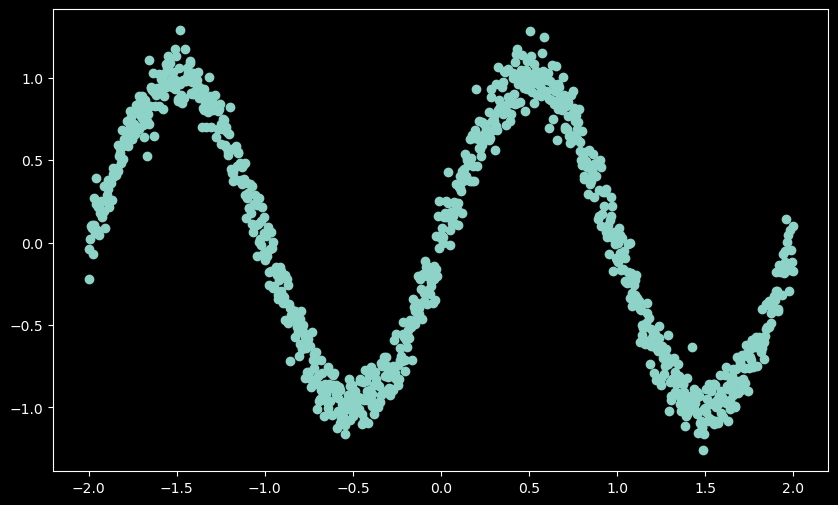

In [2]:
nPts = 1000

m = 0.5
b = 1

x = np.linspace(-2, 2, nPts)
X = x[:, np.newaxis]

#y = m*x + b
#y = x**2
y = np.sin(2*np.pi*x/2)

y += np.random.normal(0, 0.1, nPts)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Data')
plt.show()

## 2. Train/test split

Twenty percent is held out. Every model is fit on the blue points only and judged on the red ones,
which is the only way to detect a model that has memorized rather than learned.

`x_ext` is defined here too, running from $-4$ to $4$ — double the range of the training data. It is
not used until section 4, where it drives the extrapolation panel.

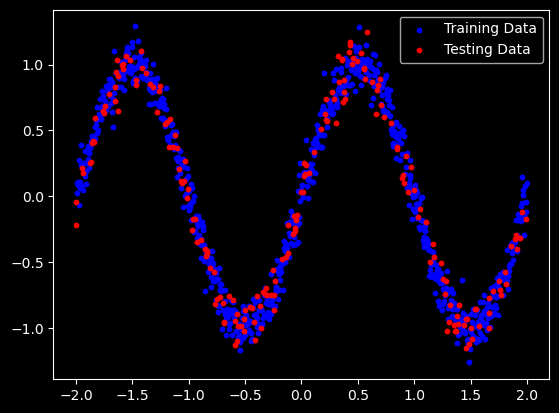

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

x_ext = np.linspace(-4, 4, nPts)

markersize = 10
plt.scatter(X_train[:,0], y_train, label='Training Data', c='b', s=markersize);
plt.scatter(X_test[:,0], y_test, label='Testing Data', c='r', s=markersize);
plt.legend()

## 3. The model families

Eleven models across six families. Where a family has an obvious complexity knob, several settings
are included so the effect is visible:

- **`LinearRegression`** — fits $\hat{y} = \beta_0 + \beta_1 x$. One straight line, no settings.
- **`KNeighborsRegressor`** at $k = 1, 10, 100$ — predicts the average target of the $k$ nearest
  training points. It stores the data rather than summarizing it. Small $k$ follows every wiggle;
  large $k$ smooths toward the global mean.
- **`DecisionTreeRegressor`** at depths 2, 5, 10 — splits the input range into intervals and
  predicts a constant on each, so predictions are always a **staircase**. Depth caps the number of
  steps.
- **`RandomForestRegressor`** — averages many trees fit to different bootstrap samples. Averaging
  staircases smooths the steps and cuts variance.
- **`GradientBoostingRegressor`** — fits shallow trees in sequence, each correcting the previous
  ensemble's residuals.
- **`MLPRegressor`** — a small neural network, the same idea developed properly in
  `U1-3_Regression-5_KerasIntro`.

Nothing is tuned here; the settings are chosen by hand to span a range. Choosing them properly is
what `-4_GridSearchCV` is for.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=1, weights='uniform'),
    KNeighborsRegressor(n_neighbors=10, weights='uniform'),
    KNeighborsRegressor(n_neighbors=100, weights='uniform'),
    DecisionTreeRegressor(max_depth=2),
    DecisionTreeRegressor(max_depth=5),
    DecisionTreeRegressor(max_depth=10),
    RandomForestRegressor(n_estimators=10, max_depth=5),
    RandomForestRegressor(n_estimators=100, max_depth=10),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
    MLPRegressor(hidden_layer_sizes=(30,20,10), max_iter=1000, tol=0.00001, n_iter_no_change=10)
]

## 4. Fit and compare

One loop: fit each model, score it, and draw three panels.

The scores are the coefficient of determination and the mean squared error,

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2},
\qquad
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

$R^2$ is the fraction of the target's variance the model explains, where 0 means "no better than
predicting the mean" and 1 means perfect. MSE is the average squared error in the units of $y$
squared. Both are reported on train and test, and **the gap between the two is the diagnostic**: a
model scoring far better on train than test has fit noise rather than signal.

The three panels are training fit, test fit, and — the interesting one — **extrapolation** onto
`x_ext`, which runs to $\pm 4$ while training data stopped at $\pm 2$.

LinearRegression()
 r2_train:   0.15936
 r2_test:    0.11888
 mse_train: 0.42251
 mse_test:  0.4531


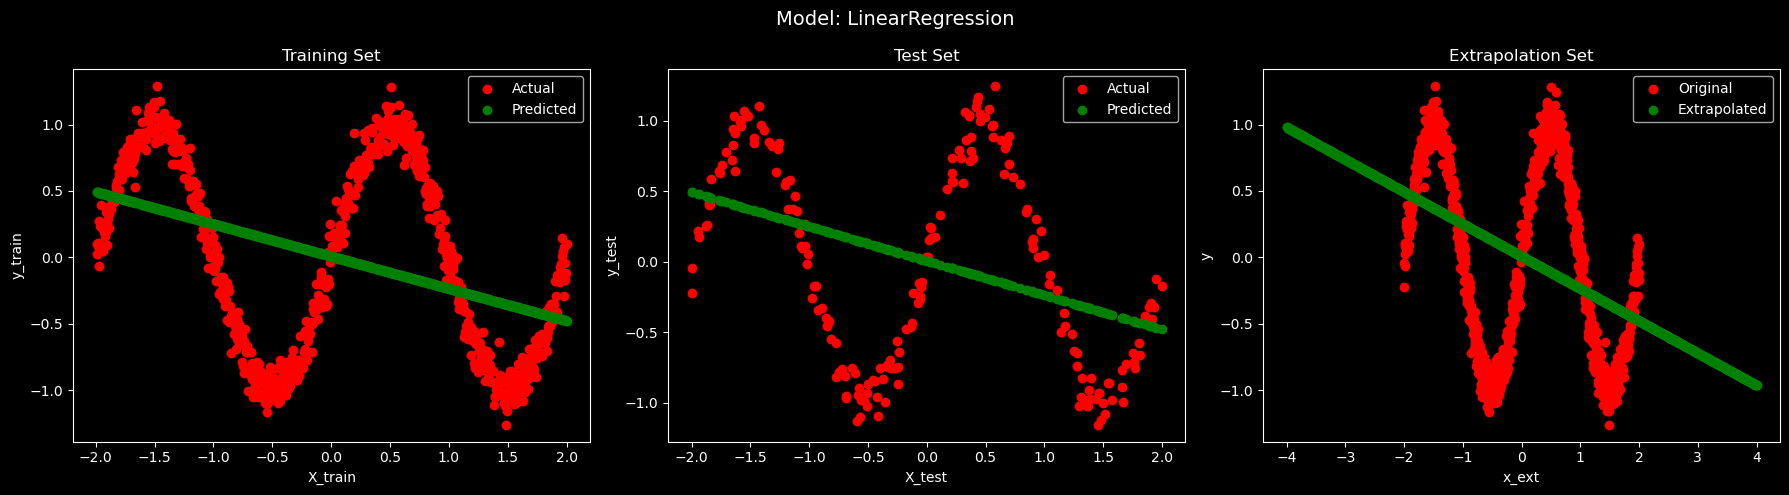


KNeighborsRegressor(n_neighbors=1)
 r2_train:   1.0
 r2_test:    0.95861
 mse_train: 0.0
 mse_test:  0.021286


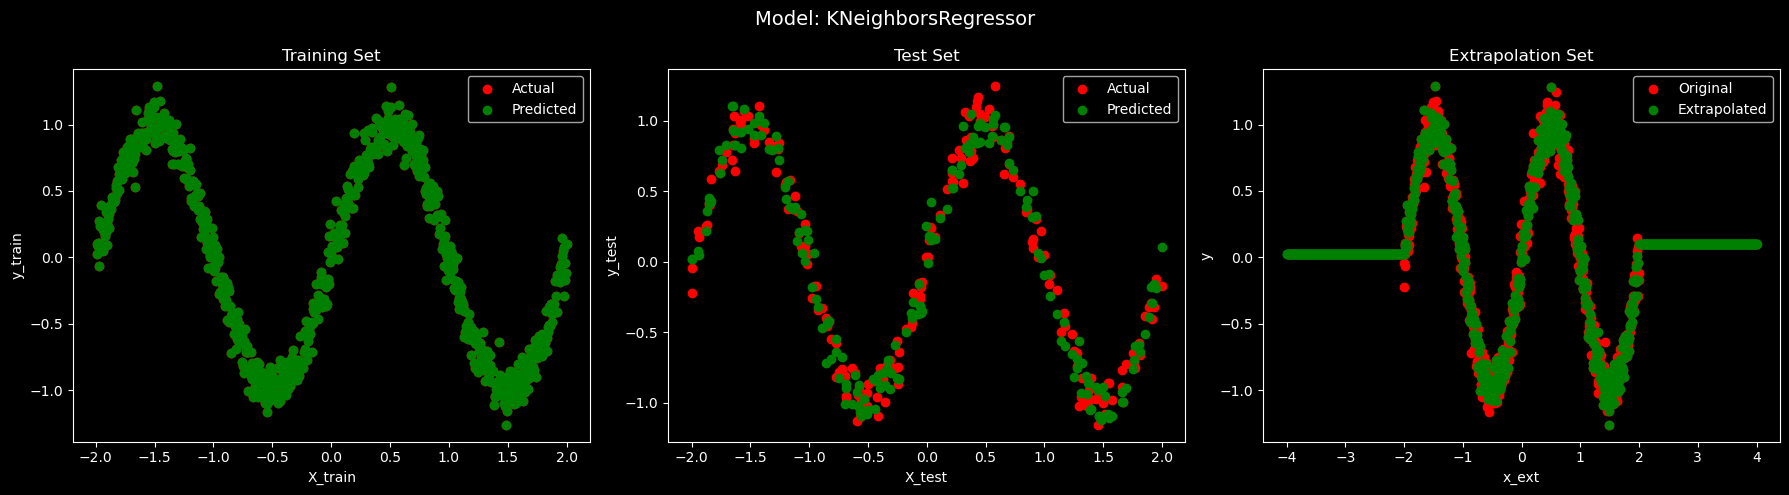


KNeighborsRegressor(n_neighbors=10)
 r2_train:   0.98274
 r2_test:    0.97491
 mse_train: 0.0086761
 mse_test:  0.0129


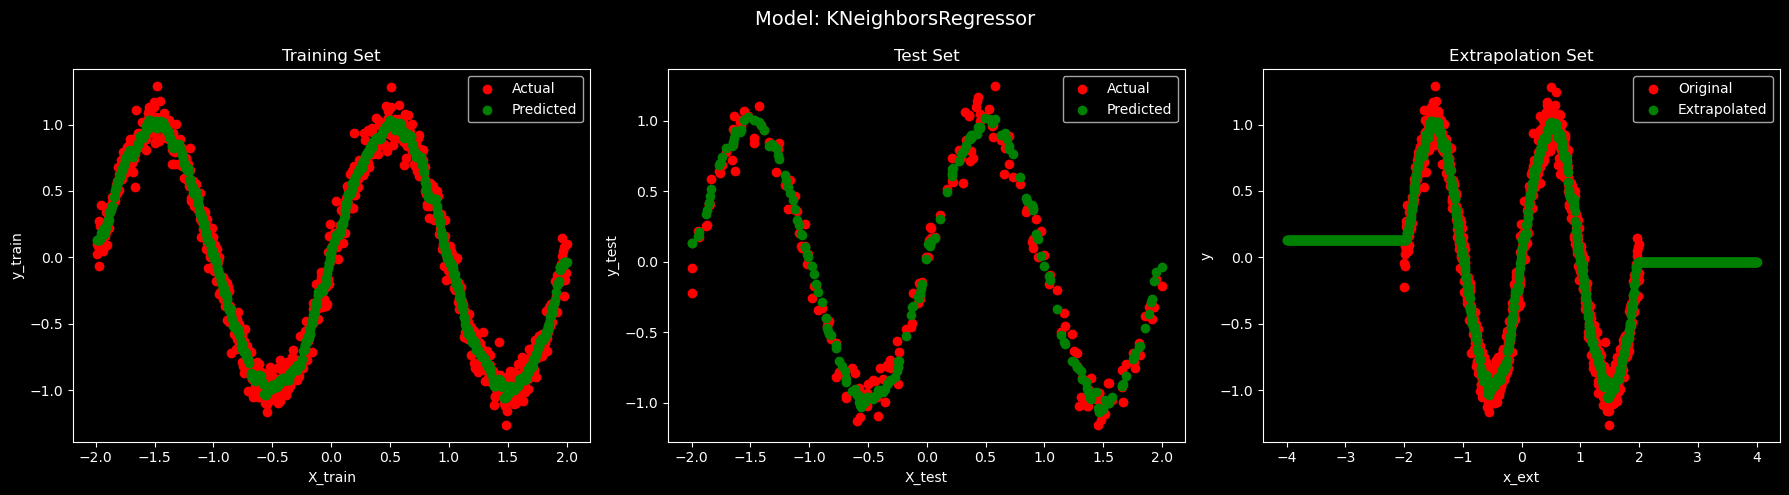


KNeighborsRegressor(n_neighbors=100)
 r2_train:   0.94214
 r2_test:    0.94374
 mse_train: 0.029082
 mse_test:  0.028931


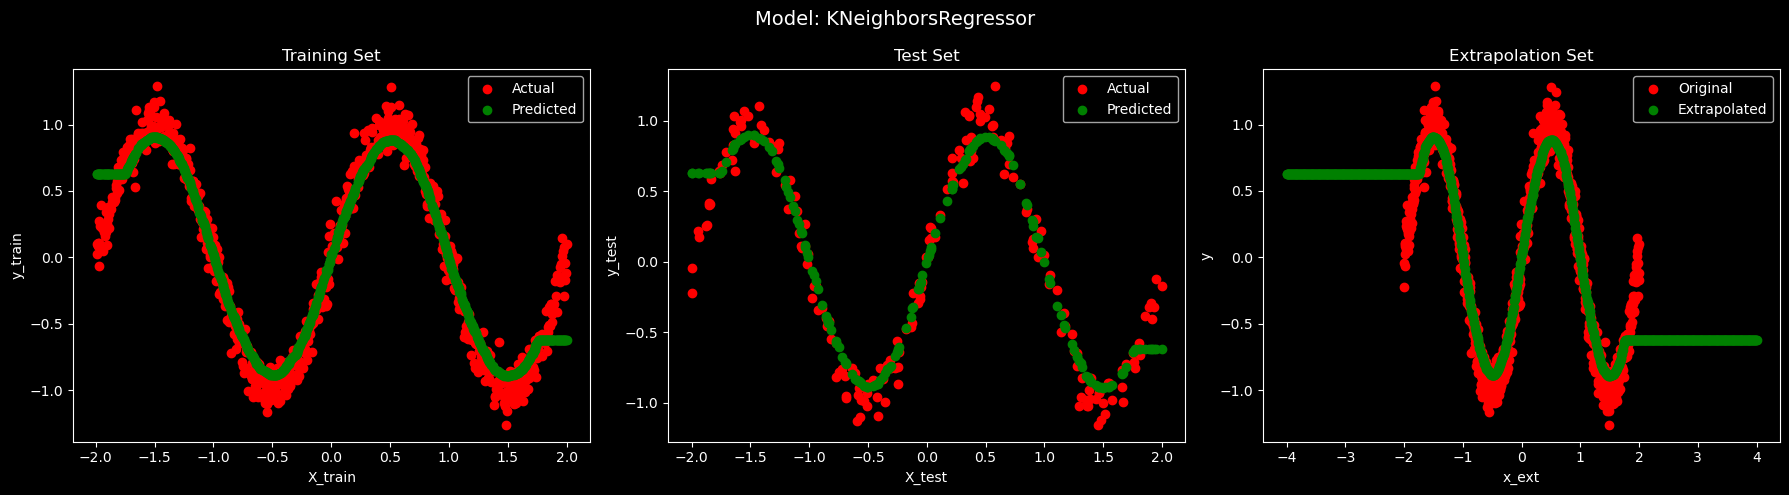


DecisionTreeRegressor(max_depth=2)
 r2_train:   0.4521
 r2_test:    0.40421
 mse_train: 0.27538
 mse_test:  0.30637


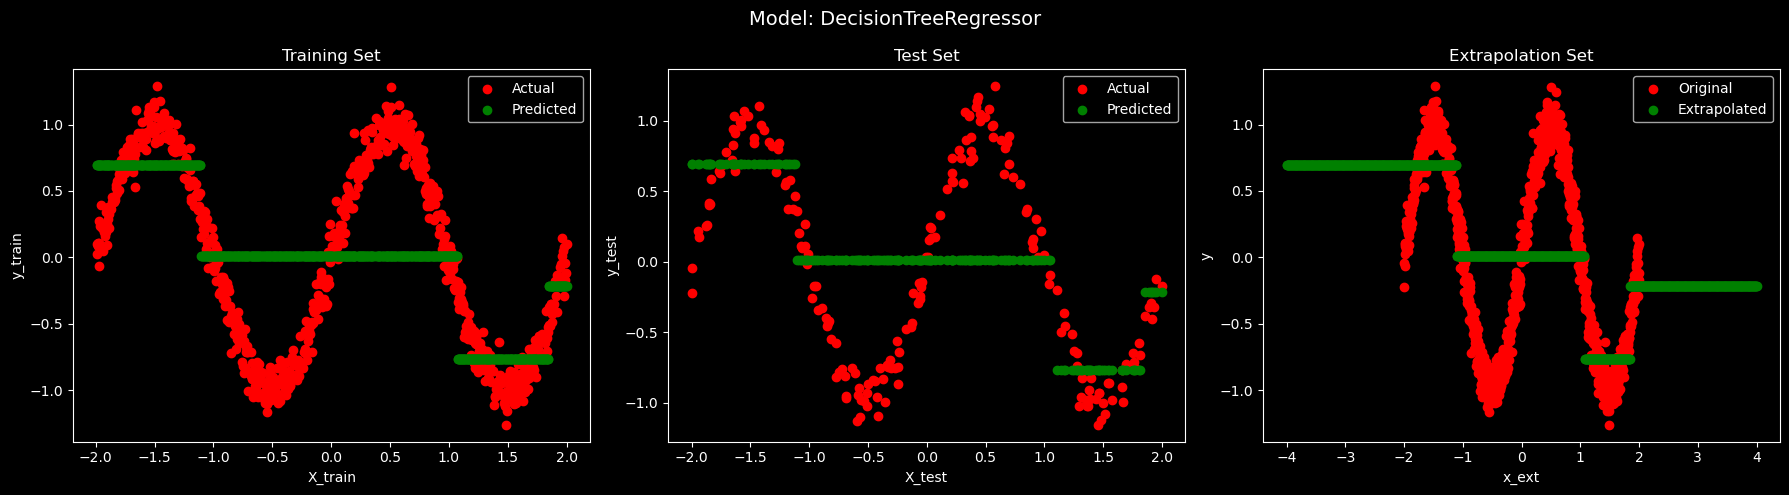


DecisionTreeRegressor(max_depth=5)
 r2_train:   0.95613
 r2_test:    0.9371
 mse_train: 0.02205
 mse_test:  0.032344


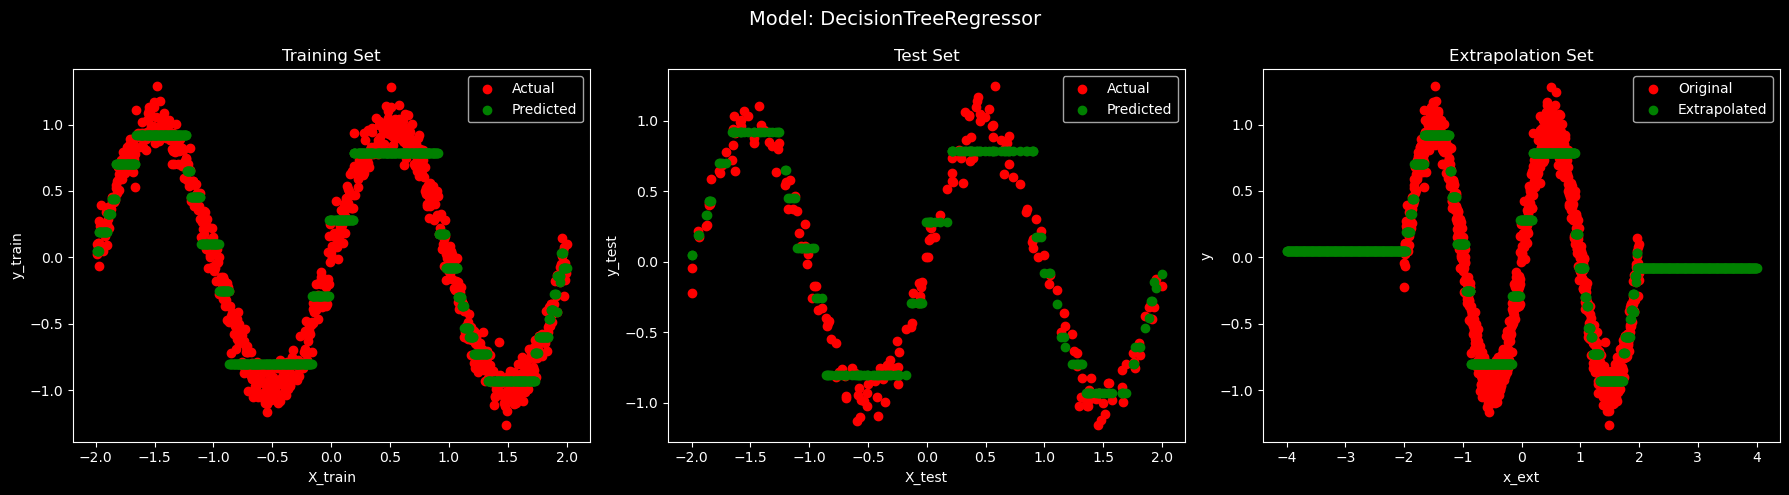


DecisionTreeRegressor(max_depth=10)
 r2_train:   0.99295
 r2_test:    0.96709
 mse_train: 0.0035418
 mse_test:  0.016925


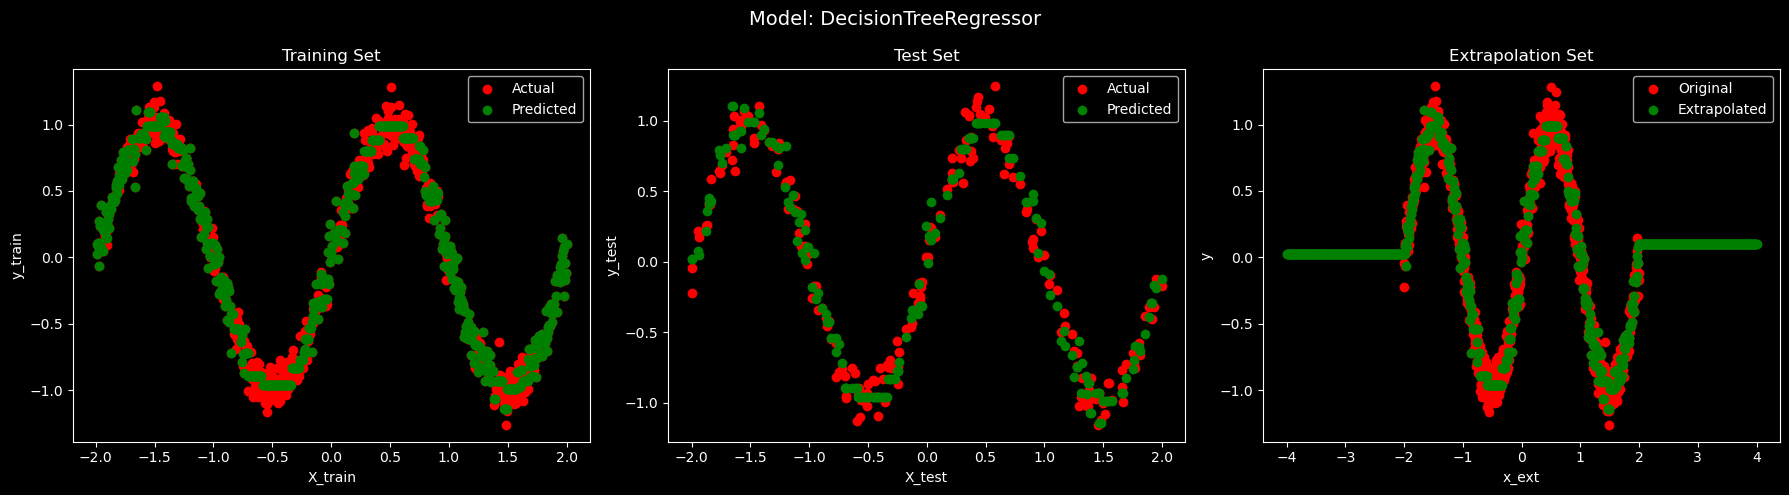


RandomForestRegressor(max_depth=5, n_estimators=10)
 r2_train:   0.96952
 r2_test:    0.95361
 mse_train: 0.015318
 mse_test:  0.023853


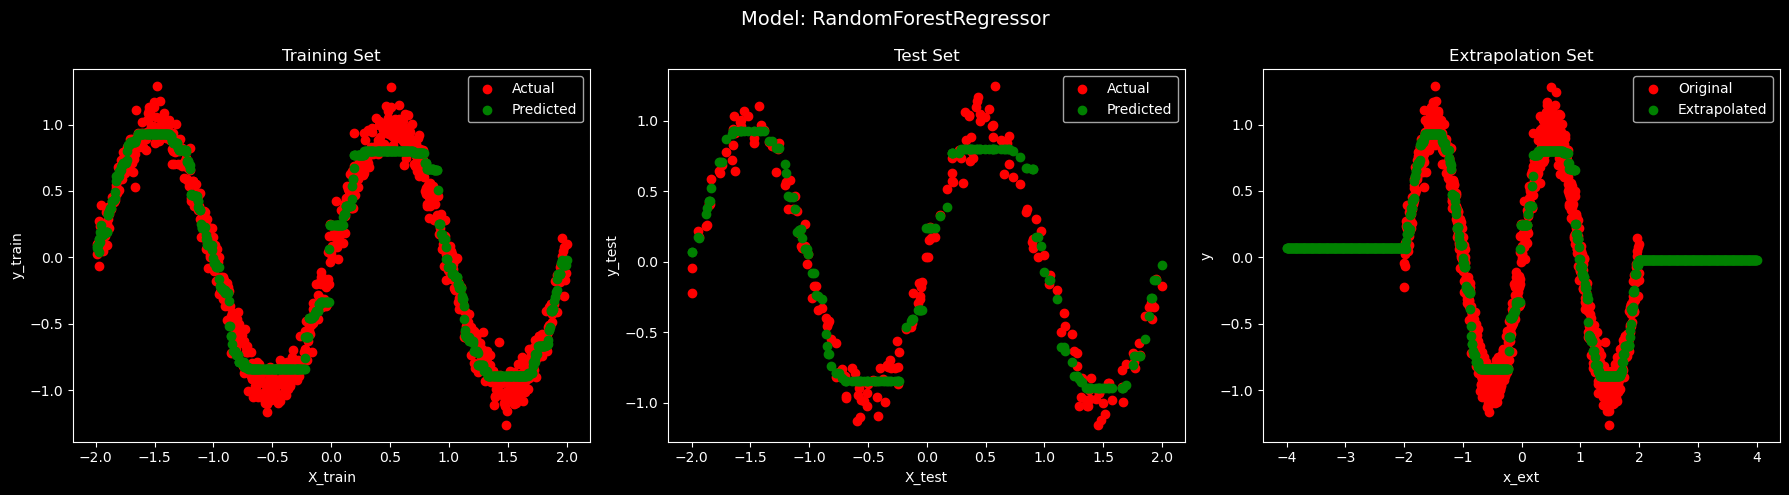


RandomForestRegressor(max_depth=10)
 r2_train:   0.99284
 r2_test:    0.973
 mse_train: 0.0035962
 mse_test:  0.013882


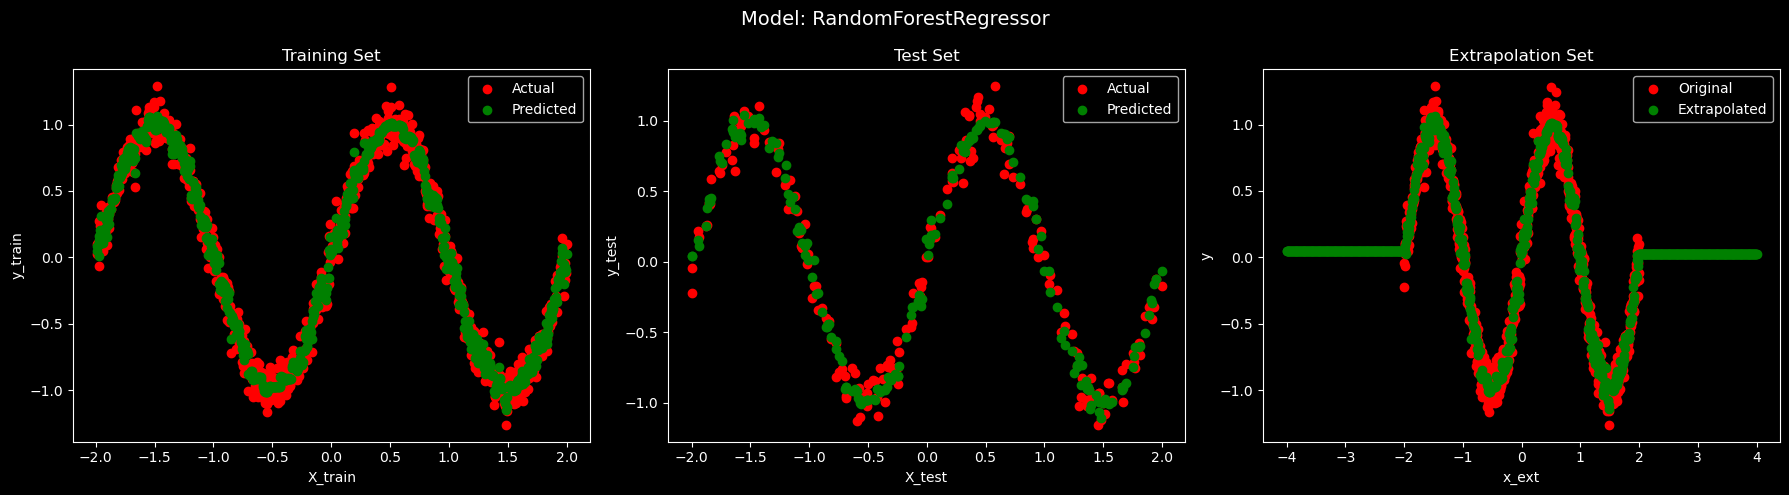


GradientBoostingRegressor(max_depth=2)
 r2_train:   0.98476
 r2_test:    0.97261
 mse_train: 0.0076576
 mse_test:  0.014083


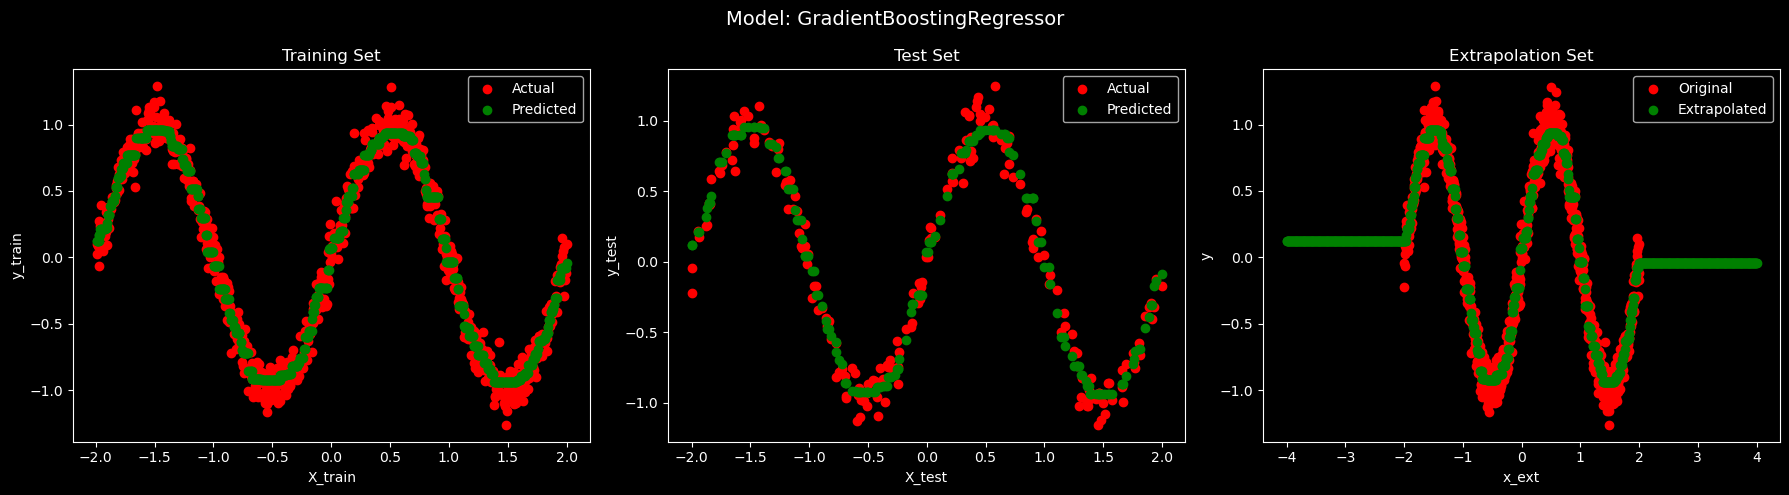

MLPRegressor(hidden_layer_sizes=(30, 20, 10), max_iter=1000, tol=1e-05)
 r2_train:   0.97329
 r2_test:    0.97507
 mse_train: 0.013424
 mse_test:  0.012822


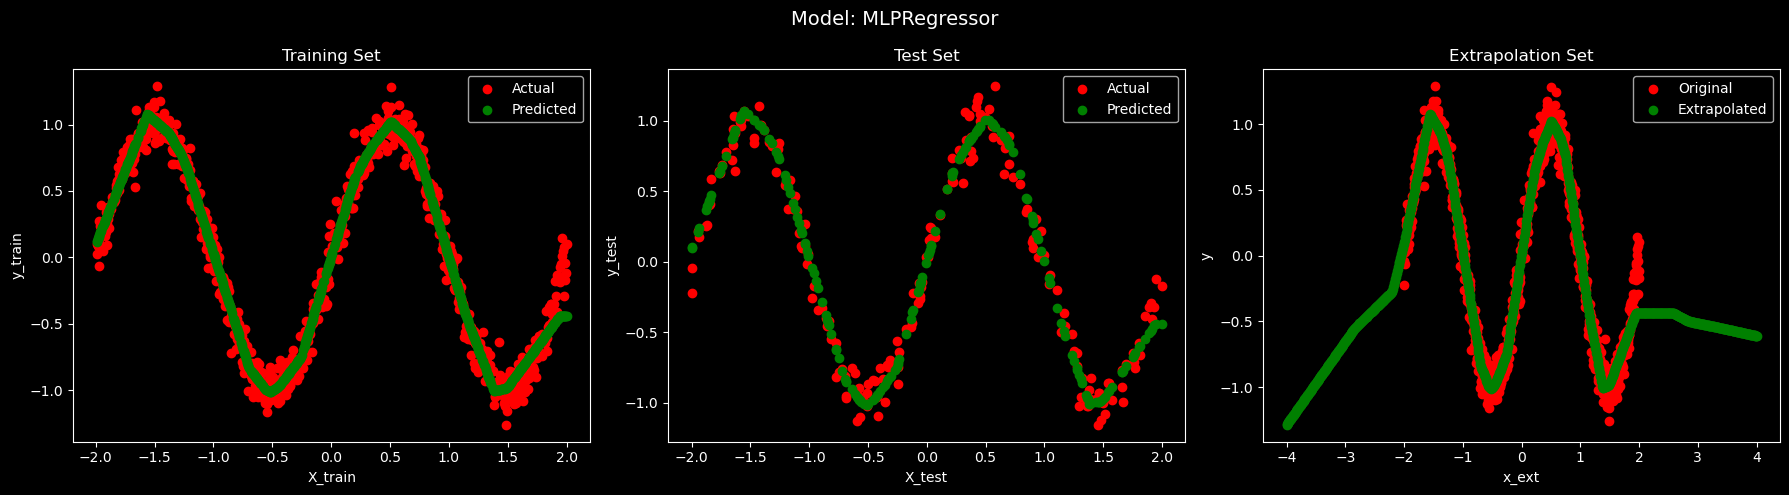

In [5]:
from sklearn.metrics import r2_score, mean_squared_error

for model in models:
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    y_ext_pred   = model.predict(x_ext[:, np.newaxis])
    
    print(model)
    
    r2_train = r2_score(y_train, y_train_pred)
    print(f' r2_train:   {r2_train:.5}')

    r2_test = r2_score(y_test, y_test_pred)
    print(f' r2_test:    {r2_test:.5}')
    
    mse_train = mean_squared_error(y_train, y_train_pred)
    print(f' mse_train: {mse_train:.5}')

    mse_test = mean_squared_error(y_test, y_test_pred)
    print(f' mse_test:  {mse_test:.5}')
    
    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Training set plot
    axes[0].scatter(X_train, y_train, color='red', label='Actual')
    axes[0].scatter(X_train, y_train_pred, color='green', label='Predicted')
    axes[0].set_title('Training Set')
    axes[0].set_xlabel('X_train')
    axes[0].set_ylabel('y_train')
    axes[0].legend()
    
    # Test set plot
    axes[1].scatter(X_test, y_test, color='red', label='Actual')
    axes[1].scatter(X_test, y_test_pred, color='green', label='Predicted')
    axes[1].set_title('Test Set')
    axes[1].set_xlabel('X_test')
    axes[1].set_ylabel('y_test')
    axes[1].legend()
    
    # Extrapolation plot
    axes[2].scatter(x, y, color='red', label='Original')
    axes[2].scatter(x_ext, y_ext_pred, color='green', label='Extrapolated')
    axes[2].set_title('Extrapolation Set')
    axes[2].set_xlabel('x_ext')
    axes[2].set_ylabel('y')
    axes[2].legend()
    
    fig.suptitle(f'Model: {model.__class__.__name__}', fontsize=14)
    plt.tight_layout()
    plt.show()
    print()
# end

Read the outputs family by family.

**Shape.** `LinearRegression` draws the one straight line it is capable of and misses the curve
entirely. The trees produce visible flat steps. KNN at $k=1$ passes through every training point —
including the noise — while $k=100$ averages so widely it nearly flattens the sine. The forest and
the boosted ensemble land closest to the true curve, and the MLP is smooth because its activations
are.

**Overfitting.** Compare $R^2$ on train against test. KNN at $k=1$ and the depth-10 tree score
near-perfectly on training data and noticeably worse on test — the signature of memorization. The
underfit models (the line, the depth-2 tree) score poorly on *both*, which is a different failure.

**Extrapolation.** Every model fails here, but each fails in its own way. Trees, forests, and KNN
are **flat** outside the training range: their prediction is a constant, because beyond the last
split or the last neighbor there is nothing left to interpolate between. `LinearRegression` shoots
off along its line forever. The MLP produces some arbitrary continuation of its final linear
pieces. None of them recovers the sine, because none of them learned "sine" — they learned a
piecewise summary of points between $-2$ and $2$.

This is the general rule, and it returns in `U1-3_Regression-5_KerasIntro`: **these models
interpolate; they do not extrapolate.** Nothing in any loss function asked them to behave sensibly
where they saw no data.

## 5. Review

- **One interface, several different assumptions.** `fit`/`predict` is shared, but each family
  imposes a characteristic shape: a line, a staircase, a local average, or a smooth curve.
- **Model complexity is a dial, not a direction.** KNN at $k=1$ and a depth-10 tree overfit; KNN at
  $k=100$ and a depth-2 tree underfit. Neither extreme is good.
- **Overfitting shows up as a train-versus-test gap**, not as a bad training score. A model that
  scores perfectly on training data and poorly on held-out data has memorized noise.
- **Ensembles help.** Averaging many trees (random forest) or fitting them to each other's
  residuals (gradient boosting) beats any single tree here.
- **None of these models extrapolates.** Tree-based models and KNN go flat outside the training
  range; linear models continue their line. Predictions outside the range of the training data are
  not trustworthy.
- The settings used here were picked by hand. `-3_CrossValidation` and `-4_GridSearchCV` replace
  that guesswork with a search.